In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from warnings import filterwarnings
filterwarnings(action='ignore')

In [6]:
df=pd.read_csv(r'AAPL_historical_data.csv')

In [17]:
df

,Date,Open,High,Low,Close
0,1980-12-12 05:00:00+00:00,0.098834,0.099264,0.098834,0.098834
1,1980-12-15 05:00:00+00:00,0.094108,0.094108,0.093678,0.093678
2,1980-12-16 05:00:00+00:00,0.087232,0.087232,0.086802,0.086802
3,1980-12-17 05:00:00+00:00,0.088951,0.089381,0.088951,0.088951
4,1980-12-18 05:00:00+00:00,0.091530,0.091959,0.091530,0.091530
...,...,...,...,...,...
11089,2024-12-09 05:00:00+00:00,241.830002,247.240005,241.750000,246.750000
11090,2024-12-10 05:00:00+00:00,246.889999,248.210007,245.339996,247.770004
11091,2024-12-11 05:00:00+00:00,247.960007,250.800003,246.259995,246.490005
11092,2024-12-12 05:00:00+00:00,246.889999,248.740005,245.679993,247.960007


In [20]:
df.shape[0]

11094

In [32]:
df.describe()

,Open,High,Low,Close
count,11094.000000,11094.000000,11094.000000,11094.000000
mean,23.236654,23.484468,23.001626,23.254564
std,49.129620,49.645173,48.654514,49.178271
min,0.038245,0.038245,0.037815,0.037815
25%,0.242896,0.248067,0.237920,0.242953
50%,0.442782,0.451501,0.435876,0.444634
75%,18.083088,18.278464,17.904287,18.107803
max,247.960007,250.800003,246.259995,248.130005


In [33]:
df.info

<bound method DataFrame.info of                            Date        Open        High         Low  \
0     1980-12-12 05:00:00+00:00    0.098834    0.099264    0.098834   
1     1980-12-15 05:00:00+00:00    0.094108    0.094108    0.093678   
2     1980-12-16 05:00:00+00:00    0.087232    0.087232    0.086802   
3     1980-12-17 05:00:00+00:00    0.088951    0.089381    0.088951   
4     1980-12-18 05:00:00+00:00    0.091530    0.091959    0.091530   
...                         ...         ...         ...         ...   
11089 2024-12-09 05:00:00+00:00  241.830002  247.240005  241.750000   
11090 2024-12-10 05:00:00+00:00  246.889999  248.210007  245.339996   
11091 2024-12-11 05:00:00+00:00  247.960007  250.800003  246.259995   
11092 2024-12-12 05:00:00+00:00  246.889999  248.740005  245.679993   
11093 2024-12-13 05:00:00+00:00  247.820007  249.289993  246.240005   

            Close    Month  
0        0.098834  1980-12  
1        0.093678  1980-12  
2        0.086802  1980-12  

In [22]:
df.isnull().sum()

Date     0
Open     0
High     0
Low      0
Close    0
dtype: int64

In [24]:
df.dtypes

Date     datetime64[ns, UTC]
Open                 float64
High                 float64
Low                  float64
Close                float64
dtype: object

In [28]:
'''Open → start price
High → peak price
Low → lowest price
Close → end price'''
df['Month']=df['Date'].dt.to_period('M')
df

,Date,Open,High,Low,Close,Month
0,1980-12-12 05:00:00+00:00,0.098834,0.099264,0.098834,0.098834,1980-12
1,1980-12-15 05:00:00+00:00,0.094108,0.094108,0.093678,0.093678,1980-12
2,1980-12-16 05:00:00+00:00,0.087232,0.087232,0.086802,0.086802,1980-12
3,1980-12-17 05:00:00+00:00,0.088951,0.089381,0.088951,0.088951,1980-12
4,1980-12-18 05:00:00+00:00,0.091530,0.091959,0.091530,0.091530,1980-12
...,...,...,...,...,...,...
11089,2024-12-09 05:00:00+00:00,241.830002,247.240005,241.750000,246.750000,2024-12
11090,2024-12-10 05:00:00+00:00,246.889999,248.210007,245.339996,247.770004,2024-12
11091,2024-12-11 05:00:00+00:00,247.960007,250.800003,246.259995,246.490005,2024-12
11092,2024-12-12 05:00:00+00:00,246.889999,248.740005,245.679993,247.960007,2024-12


In [30]:
df.Date.unique

<bound method Series.unique of 0       1980-12-12 05:00:00+00:00
1       1980-12-15 05:00:00+00:00
2       1980-12-16 05:00:00+00:00
3       1980-12-17 05:00:00+00:00
4       1980-12-18 05:00:00+00:00
                   ...           
11089   2024-12-09 05:00:00+00:00
11090   2024-12-10 05:00:00+00:00
11091   2024-12-11 05:00:00+00:00
11092   2024-12-12 05:00:00+00:00
11093   2024-12-13 05:00:00+00:00
Name: Date, Length: 11094, dtype: datetime64[ns, UTC]>

In [35]:
df.duplicated().sum()

0

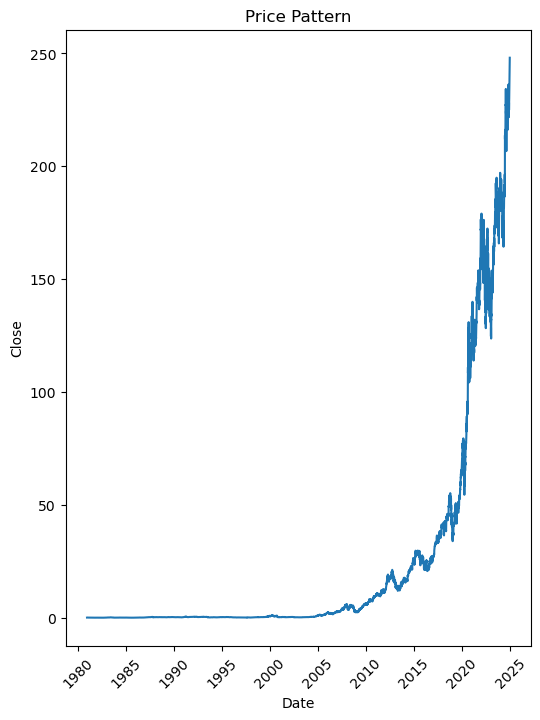

In [41]:
#Date vs Close trend or Price Pattern
plt.figure(figsize=(6,8))
sns.lineplot(data=df,x='Date',y='Close')
plt.title('Price Pattern')
plt.xticks(rotation=45)
plt.show()


<Axes: xlabel='Date', ylabel='Cumulative_growth'>

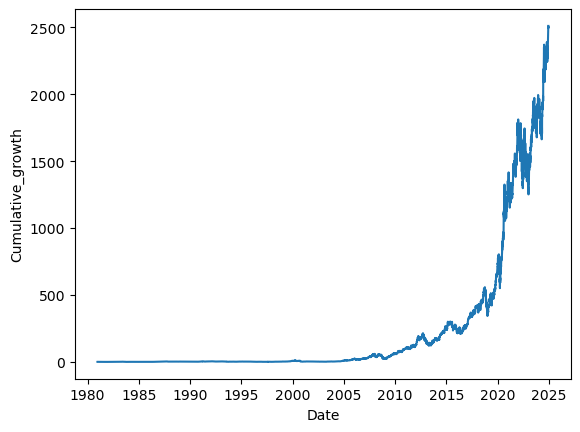

In [42]:
#Cumulative growth
df['Cumulative_growth'] = (1 + df['Close'].pct_change()).cumprod()
sns.lineplot(data=df, x='Date', y='Cumulative_growth')

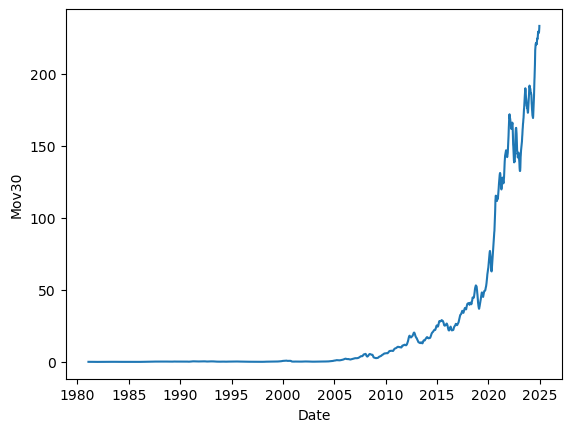

In [44]:
## Moving average growth pattern
df['Mov30']=df['Close'].rolling(30).mean()
sns.lineplot(data=df,x='Date',y='Mov30')
plt.show()

In [46]:
#Price Change
df['Price_change'] = df['Close'] - df['Open']
df

,Date,Open,High,Low,Close,Month,Cumulative_growth,Mov30,Price_change
0,1980-12-12 05:00:00+00:00,0.098834,0.099264,0.098834,0.098834,1980-12,NaN,NaN,0.000000
1,1980-12-15 05:00:00+00:00,0.094108,0.094108,0.093678,0.093678,1980-12,0.947829,NaN,-0.000430
2,1980-12-16 05:00:00+00:00,0.087232,0.087232,0.086802,0.086802,1980-12,0.878260,NaN,-0.000430
3,1980-12-17 05:00:00+00:00,0.088951,0.089381,0.088951,0.088951,1980-12,0.899998,NaN,0.000000
4,1980-12-18 05:00:00+00:00,0.091530,0.091959,0.091530,0.091530,1980-12,0.926091,NaN,0.000000
...,...,...,...,...,...,...,...,...,...
11089,2024-12-09 05:00:00+00:00,241.830002,247.240005,241.750000,246.750000,2024-12,2496.598043,231.164206,4.919998
11090,2024-12-10 05:00:00+00:00,246.889999,248.210007,245.339996,247.770004,2024-12,2506.918370,231.651756,0.880005
11091,2024-12-11 05:00:00+00:00,247.960007,250.800003,246.259995,246.490005,2024-12,2493.967438,232.087650,-1.470001
11092,2024-12-12 05:00:00+00:00,246.889999,248.740005,245.679993,247.960007,2024-12,2508.840801,232.691413,1.070007


In [47]:
#Daily Growth
df['Growth_%'] = df['Close'].pct_change()*100

In [48]:
df

,Date,Open,High,Low,Close,Month,Cumulative_growth,Mov30,Price_change,Growth_%
0,1980-12-12 05:00:00+00:00,0.098834,0.099264,0.098834,0.098834,1980-12,NaN,NaN,0.000000,NaN
1,1980-12-15 05:00:00+00:00,0.094108,0.094108,0.093678,0.093678,1980-12,0.947829,NaN,-0.000430,-5.217062
2,1980-12-16 05:00:00+00:00,0.087232,0.087232,0.086802,0.086802,1980-12,0.878260,NaN,-0.000430,-7.339819
3,1980-12-17 05:00:00+00:00,0.088951,0.089381,0.088951,0.088951,1980-12,0.899998,NaN,0.000000,2.475112
4,1980-12-18 05:00:00+00:00,0.091530,0.091959,0.091530,0.091530,1980-12,0.926091,NaN,0.000000,2.899240
...,...,...,...,...,...,...,...,...,...,...
11089,2024-12-09 05:00:00+00:00,241.830002,247.240005,241.750000,246.750000,2024-12,2496.598043,231.164206,4.919998,1.610115
11090,2024-12-10 05:00:00+00:00,246.889999,248.210007,245.339996,247.770004,2024-12,2506.918370,231.651756,0.880005,0.413376
11091,2024-12-11 05:00:00+00:00,247.960007,250.800003,246.259995,246.490005,2024-12,2493.967438,232.087650,-1.470001,-0.516608
11092,2024-12-12 05:00:00+00:00,246.889999,248.740005,245.679993,247.960007,2024-12,2508.840801,232.691413,1.070007,0.596374


In [49]:
#Growth within a day
df['Daily_range'] = df['High'] - df['Low']

In [50]:
df

,Date,Open,High,Low,Close,Month,Cumulative_growth,Mov30,Price_change,Growth_%,Daily_range
0,1980-12-12 05:00:00+00:00,0.098834,0.099264,0.098834,0.098834,1980-12,NaN,NaN,0.000000,NaN,0.000430
1,1980-12-15 05:00:00+00:00,0.094108,0.094108,0.093678,0.093678,1980-12,0.947829,NaN,-0.000430,-5.217062,0.000430
2,1980-12-16 05:00:00+00:00,0.087232,0.087232,0.086802,0.086802,1980-12,0.878260,NaN,-0.000430,-7.339819,0.000430
3,1980-12-17 05:00:00+00:00,0.088951,0.089381,0.088951,0.088951,1980-12,0.899998,NaN,0.000000,2.475112,0.000430
4,1980-12-18 05:00:00+00:00,0.091530,0.091959,0.091530,0.091530,1980-12,0.926091,NaN,0.000000,2.899240,0.000430
...,...,...,...,...,...,...,...,...,...,...,...
11089,2024-12-09 05:00:00+00:00,241.830002,247.240005,241.750000,246.750000,2024-12,2496.598043,231.164206,4.919998,1.610115,5.490005
11090,2024-12-10 05:00:00+00:00,246.889999,248.210007,245.339996,247.770004,2024-12,2506.918370,231.651756,0.880005,0.413376,2.870010
11091,2024-12-11 05:00:00+00:00,247.960007,250.800003,246.259995,246.490005,2024-12,2493.967438,232.087650,-1.470001,-0.516608,4.540009
11092,2024-12-12 05:00:00+00:00,246.889999,248.740005,245.679993,247.960007,2024-12,2508.840801,232.691413,1.070007,0.596374,3.060013


In [52]:
#How strongly are Open and Close related?
df[['Open','Close']].corr()

,Open,Close
Open,1.000000,0.999885
Close,0.999885,1.000000


In [54]:
df[['High','Low']].corr()

,High,Low
High,1.000000,0.999929
Low,0.999929,1.000000


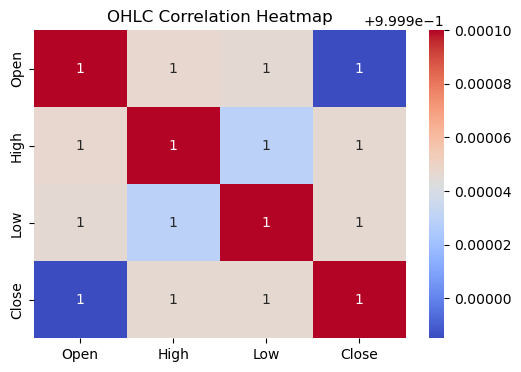

In [56]:
corr = df[['Open','High','Low','Close']].corr()
plt.figure(figsize=(6,4))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("OHLC Correlation Heatmap")
plt.show()